<img src="logos/logo_Facyt.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Pokemon Dataset – Professional Exploratory Data Analysis

## Project Context

This notebook presents a rigorous exploratory data analysis (EDA) of the Pokemon Dataset. It has a CSV Pokedex and a CSV of battles.

The objective is not merely descriptive exploration, but the systematic identification of:

- Structural patterns in the data
- Data quality issues
- Missingness mechanisms
- Variable interactions
- Feature engineering opportunities
- Modeling risks

- 1 vs 1 Pokemon Battles to winner prediction.
- Pokedex Dataset: Pokemon index by id with name, stats, generation and if it's legendary pokemon or not. 
- Pokemon Battle Dataset (`First_pokemon`, `Second_pokemon`, `Winner`).

This EDA is designed as the foundation of a full Machine Learning pipeline.

---

## Problem Definition

We aim to predict Pokemon winner (`winner`) using structured pokemon information
- **Task type**: int
- **Target variable**: `winner` (Pokemon id)
---

## Methodological Standard

This analysis follows professional data science practices:

- Reproducible structure
- Quantified decisions
- Explicit handling of missing data
- Clear distinction between variable types
- Identification of interaction effects
- Strategic connection to modeling

Each analytical block concludes with actionable insights.

---

## Guiding Principle

If an analysis does not produce a modeling decision, it is not included.

The goal is to reduce uncertainty and prepare a robust preprocessing strategy,
not to produce decorative visualizations.

---

## Expected Outcomes

By the end of this notebook, we will have:

1. Data Quality assessment
2. Identified dominant predictors.
3. Attribute-outcome relationships findings
4. Diagnosed missingness mechanisms.
5. Detected non-linear relationships.
6. Dataset risks
7. Proposed justified feature transformations.
8. Defined a preprocessing roadmap for modeling.

This document serves as a professional reference implementation of EDA.

In [69]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 29

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

In [3]:
pokemon_path = DATA_DIR / "pokemon.csv"
pokemon_df = pd.read_csv(pokemon_path)

combat_path = DATA_DIR / "combats.csv"
combat_df = pd.read_csv(combat_path)

print(f"Pokemon dataset shape: {pokemon_df.shape}")
print(pokemon_df.head())

print(f"Combat dataset shape: {combat_df.shape}")
print(combat_df.head())


Pokemon dataset shape: (800, 12)
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation  Legendary
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65     45           1      False
1  2        Ivysaur  Grass  Poison  60      62       63       80       80     60           1      False
2  3       Venusaur  Grass  Poison  80      82       83      100      100     80           1      False
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120     80           1      False
4  5     Charmander   Fire     NaN  39      52       43       60       50     65           1      False
Combat dataset shape: (50000, 3)
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151


# Pokemon Battles EDA - Professional Standard
## Objective
Perform a rigorous exploratory data analysis to understand the Pokemon dataset and prepare justified preprocessing decisions for a future classification model.
- Determine if a Pokémon's base stats are statistically positive predictors of battle outcome.
## Target
`Winner` converts to binary classification:
$$ Y= \begin{cases}
1, \text{ if} \quad Winner = FirstPokemon\\
0, \text{ if} \quad Winner = SecondPokemon
\end{cases}
$$
## Guiding Questions
1. Does the first-place Pokémon win more often than the second-place Pokémon?
2. Which stat has the highest probability of victory?
3. Is there a positive correlation between the Speed ​​stat and the probability of victory? (in-game, fastest Pokémon attack first)
4. Is physical Attack more decisive than Special Attack in the metagame of this dataset?
5. What is the win rate of Legendary Pokémon versus non-Legendary Pokémon, and of Mega-Evolved Pokémon versus non-Mega-Evolved Pokémon?
6. Which Type 1 combinations have the highest ROI (Return on Investment) in terms of victories?
7. What impact does generation have on the probability of victory?
8. Are there high-cardinality variables that may cause noise?
9. What risks could affect modeling (imbalance, missing data bias, leakage)?

## Data Audit

In [16]:
pokemon_df.info()
combat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null

As we can see, we have some real columns:
- Pokemon:
    - HP
    - Attack
    - Defense
    - Sp. Atk
    - Sp. Def
    - Speed
Integer columns (possible categorical variables or ids)
- Pokemon:
    - '#'
    - Generation
    - Legendary
- Combats:
    - First_pokemon
    - Second_pokemon
String columns (They may have categorical values or text with useful information for extraction):
- Name
- Type1
- Type2
The target column is:
- Winner (categorical variable -> binary classification)

In [17]:
print('\nMissing ratio pokemon:')
display((pokemon_df.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame('missing_%'))

print('Missing ratio combats:')
display((combat_df.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame('missing_%'))

print('Pokemon Duplicates:', pokemon_df.duplicated().sum())
print('Combats Duplicates:', combat_df.duplicated().sum())

print('Combats Duplicates %:', (combat_df.duplicated().mean() * 100).round(2))


Missing ratio pokemon:


,missing_%
Type 2,48.25
#,0.00
Name,0.00
Type 1,0.00
HP,0.00
Attack,0.00
Defense,0.00
Sp. Atk,0.00
Sp. Def,0.00
Speed,0.00


Missing ratio combats:


,missing_%
First_pokemon,0.0
Second_pokemon,0.0
Winner,0.0


Pokemon Duplicates: 0
Combats Duplicates: 1952
Combats Duplicates %: 3.9


`Type2` is the variable with the largest number of values ​​and  the only one with null values. This is because `Type2` is the secondary type that is combined with `Type1`.

### Cardinality Deep-Dive (Data Audit, sin target)

Este bloque complementa la cardinalidad básica sin usar `Winner`:
- Cardinalidad por tabla (`pokemon` y `combats`).
- Cobertura de IDs de combates en la pokedex.
- Frecuencia de aparición por Pokémon (long tail).

Estas métricas se usan para decisiones estructurales preliminares.

In [18]:
card_pokemon = pokemon_df.nunique().sort_values(ascending=False).to_frame('pokemon_nunique')
card_combats = combat_df.nunique().sort_values(ascending=False).to_frame('combats_nunique')

print('Cardinality - pokemon_df')
display(card_pokemon)

print('Cardinality - combat_df')
display(card_combats)

# Coverage of combat ids inside pokedex
pokemon_ids = set(pokemon_df['#'].astype(int))
combat_ids = set(combat_df['First_pokemon']).union(set(combat_df['Second_pokemon']))
coverage = len(combat_ids.intersection(pokemon_ids)) / len(combat_ids) * 100
print(f'Combat ID coverage in pokedex: {coverage:.2f}%')

Cardinality - pokemon_df


,pokemon_nunique
#,800
Name,800
Attack,111
Speed,108
Sp. Atk,105
Defense,103
HP,94
Sp. Def,92
Type 2,18
Type 1,18


Cardinality - combat_df


,combats_nunique
First_pokemon,784
Second_pokemon,784
Winner,783


Combat ID coverage in pokedex: 100.00%


- In **`pokemon_df`**, the variables `#` and `Name` have a **maximum cardinality (800 unique values)**, so they act as entity identifiers and **should not be used as raw categorical variables** in a model, as they would introduce noise and high dimensionality.

- The base statistics (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`) have an **intermediate cardinality**. This is consistent with continuous/discrete numerical variables and confirms that their correct treatment is **quantitative**, not categorical.

- `Type 1` and `Type 2` have **18 unique categories**, a manageable cardinality for subsequent coding. They are variables with significant predictive potential, although `Type 2` will require special treatment due to its null values.

- `Generation` has only **6 unique values** and `Legendary` only **2**, making both categorical variables with **low cardinality** and well-suited for comparative analysis and modeling.

- In **`combat_df`**, `First_pokemon` and `Second_pokemon` have **784 unique values**, indicating a very high cardinality typical of identifiers. This reinforces the idea that **they should not be used directly as nominal variables**, but rather structural information should be derived from them.

- The variable `Winner` has **783 unique values**, slightly fewer than the number of participants in battle. This suggests that **at least one Pokémon appears in battles but never wins**, which already provides a relevant competitive signal for the EDA.

- The **coverage of battle IDs within the pokedex is 100%**, so there are no structural inconsistencies between both tables: all Pokémon used in battles exist in `pokemon_df`.

### Battles Count and WinRate
We added the WinRate, Wins, and n_combats columns, as well as calculating the average number of wins and battles, to find any possible pattern relating the likelihood of winning to some attribute of the Pokémon.

In [32]:
# Total de apariciones por Pokémon (primera + segunda posición)
appear_first = combat_df["First_pokemon"].value_counts()
appear_second = combat_df["Second_pokemon"].value_counts()
appear_total = appear_first.add(appear_second, fill_value=0)

# Total de victorias por Pokémon
wins = combat_df["Winner"].value_counts()

# Nuevo dataframe con métricas de batalla
pokemon_battles_df = pokemon_df.copy()
pokemon_battles_df["n_combats"] = pokemon_battles_df["#"].map(appear_total).fillna(0).astype(int)
pokemon_battles_df["Wins"] = pokemon_battles_df["#"].map(wins).fillna(0).astype(int)
pokemon_battles_df["WinRate"] = (
    np.where(
        pokemon_battles_df["n_combats"] > 0,
        pokemon_battles_df["Wins"] / pokemon_battles_df["n_combats"] * 100,
        0
    )
).round(2)
pokemon_battles_df.head(10)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,n_combats,Wins,WinRate
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133,37,27.82
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121,46,38.02
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132,89,67.42
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125,70,56.00
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,112,55,49.11
5,6,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False,118,64,54.24
6,7,Charizard,Fire,Flying,78,84,78,109,85,100,1,False,133,115,86.47
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False,139,119,85.61
8,9,Mega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False,135,114,84.44
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,1,False,117,19,16.24


In [34]:
print("n_combats mean: " + str(pokemon_battles_df["n_combats"].mean()))
print("WinRate mean: " + str(pokemon_battles_df["WinRate"].mean().round(2)))
print('Top 10 Best Pokemon by WinRate')
print(pokemon_battles_df[['#', 'Name', 'n_combats', 'WinRate']].sort_values(by='WinRate', ascending=False).head(10))

n_combats mean: 125.0
WinRate mean: 49.09
Top 10 Best Pokemon by WinRate
       #                      Name  n_combats  WinRate
154  155           Mega Aerodactyl        129    98.45
512  513                   Weavile        119    97.48
703  704    Tornadus Therian Forme        125    96.80
19    20             Mega Beedrill        119    96.64
153  154                Aerodactyl        141    96.45
476  477              Mega Lopunny        129    96.12
726  727                  Greninja        127    96.06
716  717  Meloetta Pirouette Forme        123    95.93
164  165             Mega Mewtwo Y        125    95.20
349  350             Mega Sharpedo        120    95.00


- The table of top Pokémon by **`WinRate`** allows us to identify the most efficient battle profiles, meaning those that convert a higher proportion of appearances into victories.

- However, `WinRate` should not be interpreted in isolation: it should always be read in conjunction with **`Wins`** and **`n_combats`** to distinguish true efficiency from mere participation volume.

- In this case, the combination of **many overall wins** and **high win percentage** suggests that the top Pokémon not only win relatively frequently but also maintain that performance across a significant number of battles.

- It can be noticed that the top 10 has a majority of mega-evolved Pokémon. This may indicate a trend.

- The **number of wins and battles** table allows us to differentiate between two distinct phenomena:

- Pokémon with **high participation volume** but average performance.

- Pokémon with **high competitive performance** and also good overall results.

- This cross-section is important because a Pokémon with many battles is not necessarily dominant, and one with a high Win Rate may not be as influential if its exposure is low.

- As an analytical criterion, Pokémon that combine:

    - a high Win Rate,

    - high Wins,

    - and a sufficient number of battles are the strongest candidates to represent real patterns of competitive advantage.

- From a modeling perspective, these results suggest that there are structural attributes capable of explaining victory, for example:

    - base stats,

    - legendary status,

    - types,

    - speed,

    - and possible special forms.

- As can be seen in the correlation matrix,
- Methodologically, Win Rate is useful for EDA, but it should not be directly incorporated as a feature if it was calculated using the entire battle database, because it would introduce target leakage.

- In summary:

    - the `WinRate` table shows **competitive efficiency**,

    - the `Wins` and `n_combats` tables show **consistency and volume**,

    - and together they allow us to identify the truly dominant Pokémon within the dataset.

## Preliminary Structural Decisions
### Pokemon
- `#` and `Name` are high-cardinality identity fields; they should not be used as raw nominal features.
- `Type 1`, `Type 2`, `Legendary`, and `Generation` are structurally informative categorical variables.
- Battle stats (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`) are quantitative predictors, not categorical attributes.

### Combat
- `First_pokemon`, `Second_pokemon`, and `Winner` are entity identifiers with high cardinality by design.
- Duplicate combats (~3.9%) indicate repeated matchups and potential representation bias.
- Preparation stage recommendation: remove exact duplicates before split and apply grouped split by unordered matchup pair.

## Analyzing the Target Variable

Operational target for modeling-oriented EDA:
- `first_wins = 1` if `Winner == First_pokemon`
- `first_wins = 0` otherwise

This block is intentionally separated from Data Audit because it depends on battle outcome.

Target distribution:
first_wins
0    52.798
1    47.202
Name: proportion, dtype: float64

Baseline naive accuracy: 52.80%
Exact duplicate combats: 3.90%


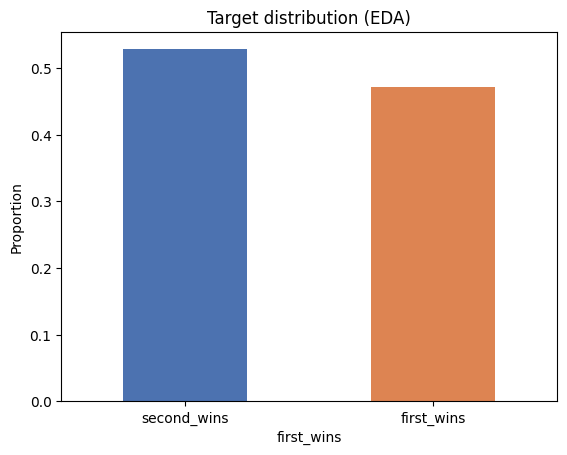

In [59]:
target_df = combat_df.copy()
target_df['first_wins'] = (target_df['Winner'] == target_df['First_pokemon']).astype(int)

target_dist = target_df['first_wins'].value_counts(normalize=True).sort_index()

print('Target distribution:')
print(target_dist * 100)


baseline_acc = target_dist.max() *100
print(f'\nBaseline naive accuracy: {baseline_acc:.2f}%')
# Exact duplicates in combats
dup_pct = combat_df.duplicated(subset=['First_pokemon', 'Second_pokemon', 'Winner']).mean() * 100
print(f'Exact duplicate combats: {dup_pct:.2f}%')
ax = target_dist.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['second_wins', 'first_wins'], rotation=0)
ax.set_ylabel('Proportion')
ax.set_title('Target distribution (EDA)')
plt.show()

53.8% win first

47.2% win second

This shows us that:
- The objective is relatively balanced
- A naive model (predict always 0) will get a 47.2% of accuracy

## Relación entre stats y probabilidad de ganar

Resumen: relación entre ventaja de stat y probabilidad de ganar


,stat,corr_with_first_wins,p1_winrate_if_higher_%,p1_winrate_if_tied_%,p1_winrate_if_lower_%,gap_higher_vs_lower_pp,higher_cases,tie_cases,lower_cases
0,Speed,0.678,92.385,0.000,4.602,87.783,24334,1328,24338
1,Stats_Total,0.470,67.052,44.518,27.216,39.836,24824,602,24574
2,Attack,0.362,62.708,45.380,31.795,30.913,24383,1223,24394
3,Sp. Atk,0.349,62.270,45.977,32.013,30.257,24418,1479,24103
4,Sp. Def,0.219,58.254,45.209,36.179,22.075,24254,1743,24003
5,HP,0.194,58.113,46.091,36.357,21.756,24055,1944,24001
6,Defense,0.079,52.377,45.855,42.076,10.301,24314,1544,24142


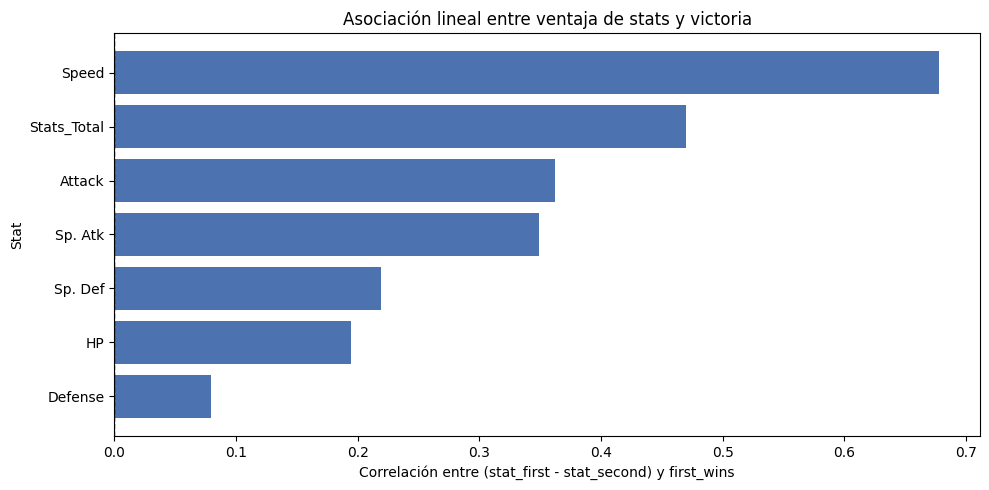

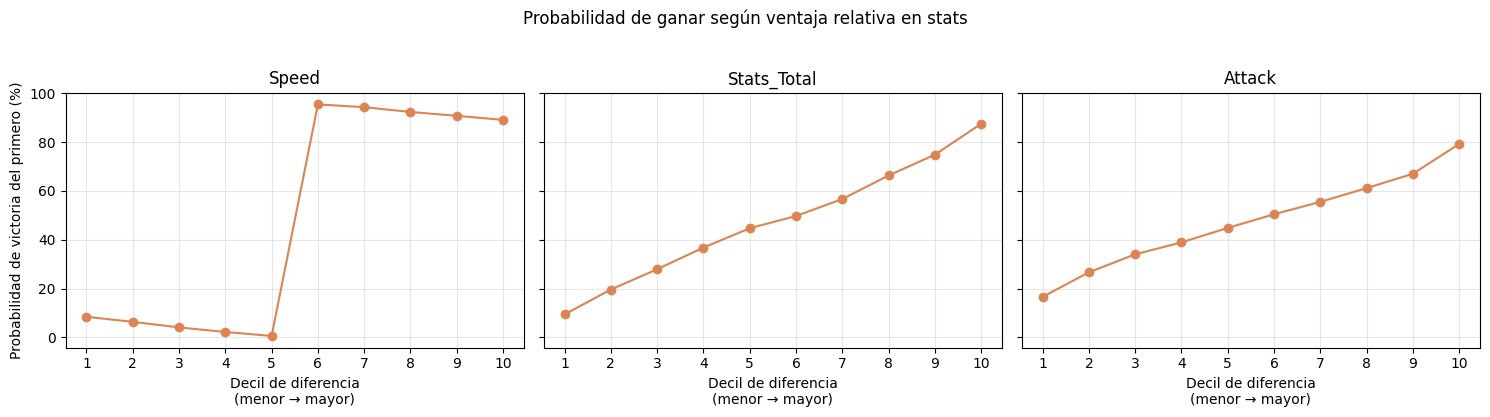

In [ ]:
# Usa variables ya existentes: pokemon_df, target_df, FIG_DIR

stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Tabla base de stats por Pokémon
stats_lookup = pokemon_df.set_index('#')[stats_cols].copy()
stats_lookup['Stats_Total'] = stats_lookup.sum(axis=1)
analysis_stats = stats_cols + ['Stats_Total']

# Construcción del dataset de combate a nivel batalla
battle_stats_df = target_df[['First_pokemon', 'Second_pokemon', 'first_wins']].copy()

for stat in analysis_stats:
    battle_stats_df[f'first_{stat}'] = battle_stats_df['First_pokemon'].map(stats_lookup[stat])
    battle_stats_df[f'second_{stat}'] = battle_stats_df['Second_pokemon'].map(stats_lookup[stat])
    battle_stats_df[f'diff_{stat}'] = battle_stats_df[f'first_{stat}'] - battle_stats_df[f'second_{stat}']

# Resumen numérico por stat
summary_rows = []

for stat in analysis_stats:
    diff_col = f'diff_{stat}'
    diff = battle_stats_df[diff_col]

    higher_mask = diff > 0
    tie_mask = diff == 0
    lower_mask = diff < 0

    winrate_higher = battle_stats_df.loc[higher_mask, 'first_wins'].mean() * 100
    winrate_tie = battle_stats_df.loc[tie_mask, 'first_wins'].mean() * 100 if tie_mask.any() else np.nan
    winrate_lower = battle_stats_df.loc[lower_mask, 'first_wins'].mean() * 100

    summary_rows.append({
        'stat': stat,
        'corr_with_first_wins': battle_stats_df[diff_col].corr(battle_stats_df['first_wins']),
        'p1_winrate_if_higher_%': winrate_higher,
        'p1_winrate_if_tied_%': winrate_tie,
        'p1_winrate_if_lower_%': winrate_lower,
        'gap_higher_vs_lower_pp': winrate_higher - winrate_lower,
        'higher_cases': int(higher_mask.sum()),
        'tie_cases': int(tie_mask.sum()),
        'lower_cases': int(lower_mask.sum())
    })

stats_effect_df = (
    pd.DataFrame(summary_rows)
    .sort_values(['gap_higher_vs_lower_pp', 'corr_with_first_wins'], ascending=False)
    .reset_index(drop=True)
)

print('Resumen: relación entre ventaja de stat y probabilidad de ganar')
display(stats_effect_df.round(3))

# Gráfico 1: correlación entre diferencia de stats y victoria del primero
plot_df = stats_effect_df.sort_values('corr_with_first_wins', ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(plot_df['stat'], plot_df['corr_with_first_wins'], color='#4C72B0')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Correlación entre (stat_first - stat_second) y first_wins')
plt.ylabel('Stat')
plt.title('Asociación lineal entre ventaja de stats y victoria')
plt.tight_layout()
plt.savefig(FIG_DIR / 'stats_vs_win_probability_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráfico 2: win rate por deciles de diferencia para las 3 stats más influyentes
top_stats = stats_effect_df.head(3)['stat'].tolist()

fig, axes = plt.subplots(1, len(top_stats), figsize=(5 * len(top_stats), 4), sharey=True)
if len(top_stats) == 1:
    axes = [axes]

for ax, stat in zip(axes, top_stats):
    decile_df = battle_stats_df[[f'diff_{stat}', 'first_wins']].copy()
    decile_df = decile_df.rename(columns={f'diff_{stat}': 'diff'})
    decile_df['bin'] = pd.qcut(decile_df['diff'], q=10, duplicates='drop')

    trend = (
        decile_df.groupby('bin', observed=False)['first_wins']
        .mean()
        .mul(100)
        .reset_index()
    )

    ax.plot(range(len(trend)), trend['first_wins'], marker='o', color='#DD8452')
    ax.set_title(stat)
    ax.set_xlabel('Decil de diferencia\n(menor → mayor)')
    ax.set_xticks(range(len(trend)))
    ax.set_xticklabels(range(1, len(trend) + 1))
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Probabilidad de victoria del primero (%)')
fig.suptitle('Probabilidad de ganar según ventaja relativa en stats', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'stats_vs_win_probability_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

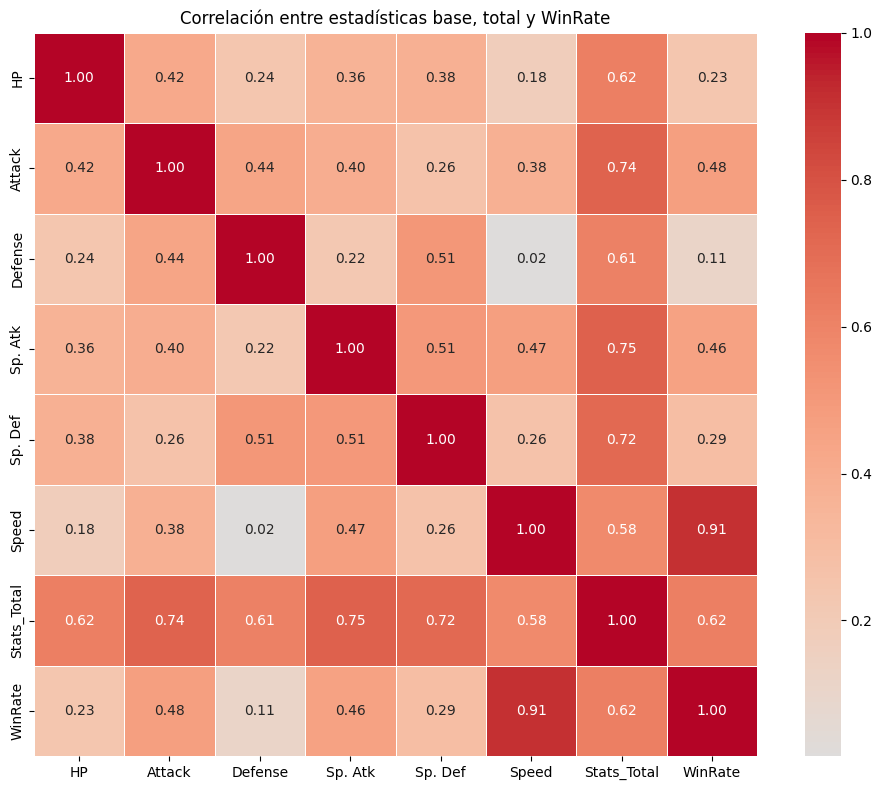

Correlación de cada estadística con WinRate:


,corr_with_WinRate
Speed,0.905410
Stats_Total,0.619735
Attack,0.476671
Sp. Atk,0.455845
Sp. Def,0.291598
HP,0.234886
Defense,0.113308


In [75]:
# Heatmap: correlación entre stats base, stat total y WinRate

if 'Stats_Total' not in pokemon_battles_df.columns:
    pokemon_battles_df['Stats_Total'] = pokemon_battles_df[stats_cols].sum(axis=1)

heatmap_cols = stats_cols + ['Stats_Total', 'WinRate']
winrate_corr_matrix = pokemon_battles_df[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    winrate_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlación entre estadísticas base, total y WinRate")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_base_stats_total_winrate.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlación de cada estadística con WinRate:")
display(
    winrate_corr_matrix['WinRate']
    .drop('WinRate')
    .sort_values(ascending=False)
    .to_frame('corr_with_WinRate')
)

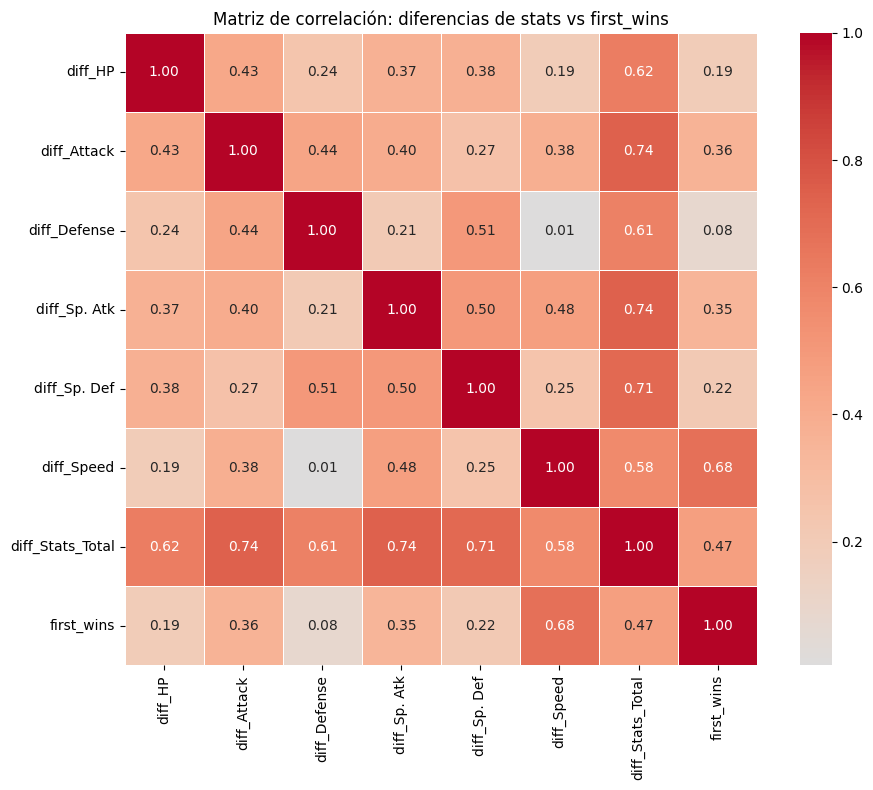

Correlación de cada stat con first_wins:


,corr_with_first_wins
diff_Speed,0.677719
diff_Stats_Total,0.470201
diff_Attack,0.361873
diff_Sp. Atk,0.348891
diff_Sp. Def,0.218823
diff_HP,0.194240
diff_Defense,0.079377


In [73]:
# Matriz de correlación entre diferencias de stats y probabilidad de victoria del primero
corr_cols = [f'diff_{stat}' for stat in analysis_stats] + ['first_wins']

corr_matrix = battle_stats_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación: diferencias de stats vs first_wins")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix_stats_vs_win.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlación de cada stat con first_wins:")
display(
    corr_matrix["first_wins"]
    .drop("first_wins")
    .sort_values(ascending=False)
    .to_frame("corr_with_first_wins")
)

1. **Speed es la stat más determinante del dataset.**  
    Es la que tiene mayor correlación con la victoria y la mayor separación entre casos con ventaja y desventaja. 
    - Tiene la mayor correlación con `WinRate` a nivel Pokémon.
    - Tiene también la mayor correlación con `first_wins` cuando se analiza la **diferencia de stats entre ambos combatientes**.

2. **La ventaja en Speed casi determina el resultado del combate.**  
    Cuando el primer Pokémon tiene más `Speed`, gana aproximadamente **92.39%** de las veces; cuando tiene menos, gana solo **4.60%**. 

3. **`Total` es la segunda variable más fuerte.**  
    Tener mayor suma total de stats también incrementa claramente la probabilidad de victoria, aunque su efecto es bastante menor que el de `Speed`. Mantiene una asociación alta tanto con `WinRate` como con `first_wins`. Si el primero tiene mejores estadísticas en su conjunto, gana 67.05% de las veces; si tiene menor Total, gana 27.22%, lo que indica que la fortaleza global del Pokémon también explica una parte importante del desempeño.

4. **Entre `Attack` y `Sp. Atk`, `Attack` es ligeramente más decisiva.**  
    Ambas tienen poder predictivo parecido, pero `Attack` muestra una ventaja marginalmente superior en separación de probabilidades.

5. **`Defense` es la stat menos influyente del conjunto analizado.**  
    Su correlación con la victoria es baja y la diferencia entre tener ventaja o desventaja es pequeña en comparación con el resto.

6. **Las curvas por deciles muestran una relación monotónica.**  
    En las stats más relevantes, cuanto mayor es la ventaja relativa del primer Pokémon, mayor es su probabilidad de ganar.

7. **Las diferencias entre stats son más informativas que las stats aisladas.**  
    La matriz basada en `diff_HP`, `diff_Attack`, `diff_Speed`, etc., muestra con mayor claridad la relación directa entre ventaja competitiva y resultado del combate.  
    Esto respalda que el modelado debe centrarse en variables relativas entre el primer y segundo Pokémon.

8. **Implicación para feature engineering:**  
    Para un modelo predictivo, conviene construir variables como:
    - `diff_HP`
    - `diff_Attack`
    - `diff_Defense`
    - `diff_Sp. Atk`
    - `diff_Sp. Def`
    - `diff_Speed`
    - `diff_Total`
    
    Sin embargo, las variables con mayor valor analítico para el modelo son:
    - `diff_Speed`
    - `diff_Stats_Total`
    - `diff_Attack`
    - `diff_Sp. Atk`

    En cambio, `diff_Defense` tendría menor prioridad relativa.

    porque capturan directamente la ventaja competitiva entre ambos participantes.
9. **Riesgo analítico importante:**  
    El comportamiento extremo de `Speed` sugiere una señal muy fuerte del dataset, pero también amerita revisión metodológica para confirmar que no existan sesgos de generación de combates o reglas implícitas que favorezcan excesivamente a la velocidad.

Combates originales: 50,000
Combates deduplicados: 48,048
Duplicados removidos: 1,952 (3.90%)
Resumen por grupo (historico descriptivo)


,pokemon_count,avg_winrate_hist,median_winrate_hist,avg_wins,avg_combats,avg_total_stats,avg_speed,legendary_rate,mega_rate
profile_group,,,,,,,,,
Normal,691,45.13,43.54,57.41,124.67,405.80,63.86,0.0,0.0
Mega,44,70.42,79.00,89.89,128.73,596.41,90.45,0.0,1.0
Legendary,59,76.70,79.70,98.19,128.05,626.95,98.25,1.0,0.0
Legendary + Mega,6,76.82,91.20,97.33,105.50,740.00,119.17,1.0,1.0


Resumen: legendarios vs no legendarios


,pokemon_count,avg_winrate_hist,median_winrate_hist,avg_total_stats,avg_speed
Legendary,,,,,
Non-Legendary,735,46.64,44.83,417.21,65.46
Legendary,65,76.72,81.34,637.38,100.18


Resumen: mega vs no mega


...

opponent,Normal,Mega,Legendary,Legendary + Mega
group,,,,
Normal,50.00,26.70,18.85,5.54
Mega,73.30,50.00,45.48,25.00
Legendary,81.15,54.52,50.00,14.00
Legendary + Mega,94.46,75.00,86.00,50.00


Cantidad de enfrentamientos por grupo


opponent,Normal,Mega,Legendary,Legendary + Mega
group,,,,
Normal,71272,4700,6259,523
Mega,4700,306,409,32
Legendary,6259,409,566,50
Legendary + Mega,523,32,50,6


Top enfrentamientos dirigidos por volumen y tasa de victoria


,group,opponent,n_battles,win_rate_pct
3,Legendary,Normal,6259,81.15
12,Normal,Legendary,6259,18.85
11,Mega,Normal,4700,73.30
14,Normal,Mega,4700,26.70
7,Legendary + Mega,Normal,523,94.46
13,Normal,Legendary + Mega,523,5.54
2,Legendary,Mega,409,54.52
8,Mega,Legendary,409,45.48
4,Legendary + Mega,Legendary,50,86.00
1,Legendary,Legendary + Mega,50,14.00


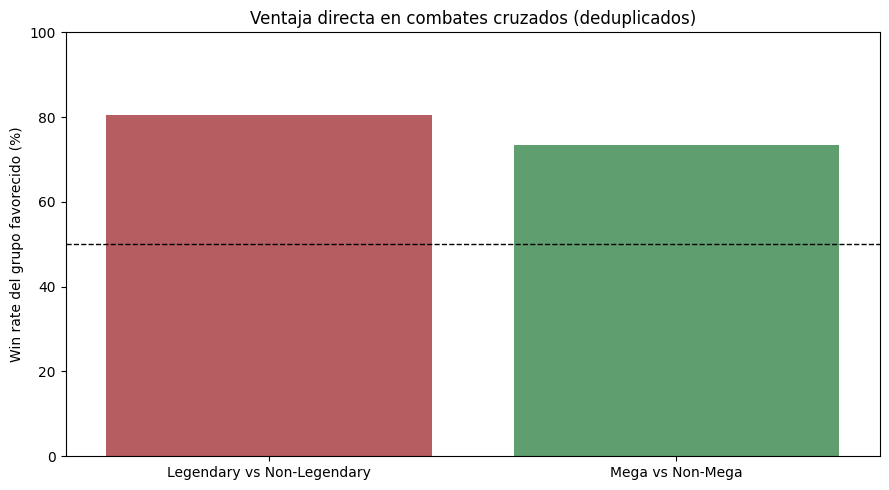

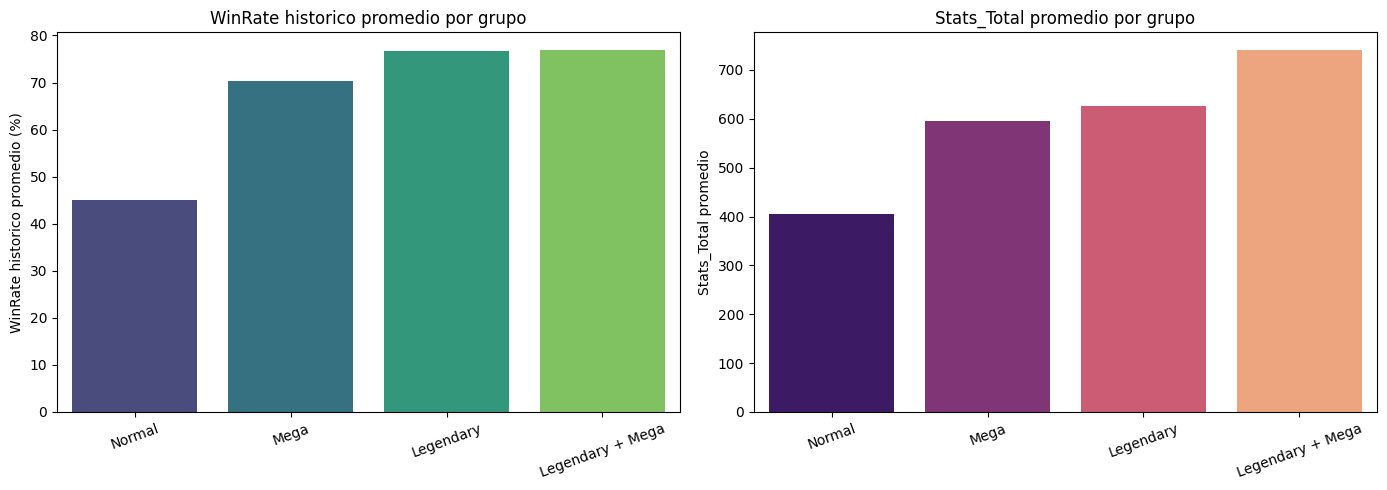

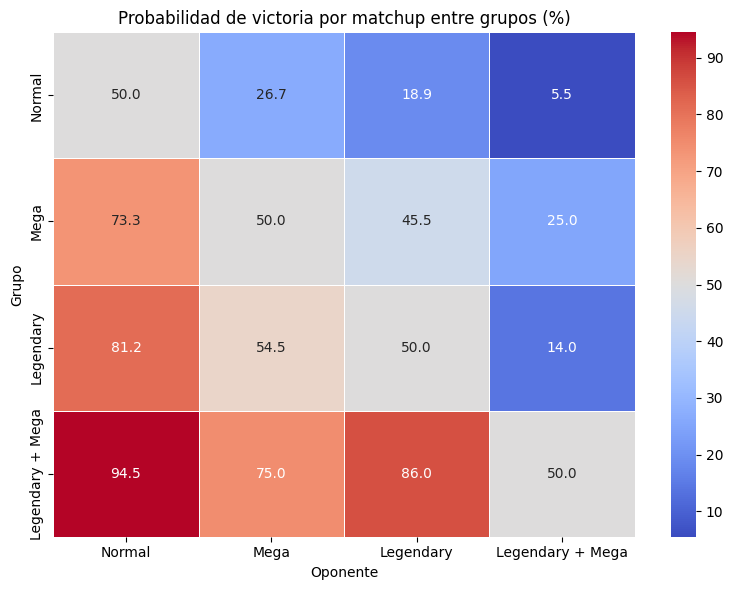


Hallazgos clave (version corregida)
- Grupo con mayor WinRate historico promedio: Legendary + Mega (76.82%).
- En duelos directos deduplicados, Legendary vs Non-Legendary: 80.58% para Legendary.
- En duelos directos deduplicados, Mega vs Non-Mega: 73.35% para Mega.
- En submuestra controlada por Speed/Total, Legendary vs Non-Legendary: 36.00% para Legendary.
- En submuestra controlada por Speed/Total, Mega vs Non-Mega: 48.78% para Mega.
- Interpretacion recomendada: asociacion descriptiva, no causalidad.


In [78]:
# Analisis comparativo corregido: legendarios vs no legendarios, mega vs no mega
# Mejoras: deduplicacion de combates, intervalos de confianza, control parcial por confusores,
# y graficos compatibles con seaborn>=0.14 (palette requiere hue).

import re

# ---------- Helpers ----------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p_hat = successes / n
    denom = 1 + (z ** 2) / n
    center = (p_hat + (z ** 2) / (2 * n)) / denom
    margin = (z / denom) * np.sqrt((p_hat * (1 - p_hat) / n) + (z ** 2) / (4 * (n ** 2)))
    return center - margin, center + margin


def summarize_advantaged_winrate(df, label, advantaged_label):
    n = len(df)
    wins = int(df["advantaged_wins"].sum())
    p = wins / n if n > 0 else np.nan
    low, high = wilson_ci(wins, n)
    return {
        "comparison": label,
        "n_battles": n,
        "advantaged_group": advantaged_label,
        "advantaged_group_winrate_%": p * 100 if n > 0 else np.nan,
        "ci95_low_%": low * 100 if n > 0 else np.nan,
        "ci95_high_%": high * 100 if n > 0 else np.nan,
        "other_group_winrate_%": (1 - p) * 100 if n > 0 else np.nan,
    }


# ---------- 1) Base de Pokemon con perfiles ----------
pokemon_profile_df = pokemon_battles_df.copy()

# El dataset usa nombres con variaciones de mega; este criterio textual es aproximado.
pokemon_profile_df["is_mega"] = pokemon_profile_df["Name"].str.contains("Mega", case=False, na=False)

pokemon_profile_df["profile_group"] = np.select(
    [
        pokemon_profile_df["Legendary"] & pokemon_profile_df["is_mega"],
        pokemon_profile_df["Legendary"] & ~pokemon_profile_df["is_mega"],
        ~pokemon_profile_df["Legendary"] & pokemon_profile_df["is_mega"],
    ],
    ["Legendary + Mega", "Legendary", "Mega"],
    default="Normal",
)

group_order = ["Normal", "Mega", "Legendary", "Legendary + Mega"]

pokemon_group_summary = (
    pokemon_profile_df.groupby("profile_group", observed=False)
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_wins=("Wins", "mean"),
        avg_combats=("n_combats", "mean"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
        legendary_rate=("Legendary", "mean"),
        mega_rate=("is_mega", "mean"),
    )
    .reindex(group_order)
    .round(2)
)

legendary_summary = (
    pokemon_profile_df.groupby("Legendary")
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
    )
    .rename(index={False: "Non-Legendary", True: "Legendary"})
    .round(2)
)

mega_summary = (
    pokemon_profile_df.groupby("is_mega")
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
    )
    .rename(index={False: "Non-Mega", True: "Mega"})
    .round(2)
)


# ---------- 2) Base de combates deduplicada (sensibilidad a sesgo por repeticion) ----------
combat_model_df = combat_df.drop_duplicates(subset=["First_pokemon", "Second_pokemon", "Winner"]).copy()
removed_duplicates = len(combat_df) - len(combat_model_df)
print(f"Combates originales: {len(combat_df):,}")
print(f"Combates deduplicados: {len(combat_model_df):,}")
print(f"Duplicados removidos: {removed_duplicates:,} ({removed_duplicates / len(combat_df) * 100:.2f}%)")

battle_group_df = combat_model_df[["First_pokemon", "Second_pokemon", "Winner"]].copy()
battle_group_df["first_wins"] = (battle_group_df["Winner"] == battle_group_df["First_pokemon"]).astype(int)

legend_lookup = pokemon_profile_df.set_index("#")["Legendary"]
mega_lookup = pokemon_profile_df.set_index("#")["is_mega"]
profile_lookup = pokemon_profile_df.set_index("#")["profile_group"].astype(str)
speed_lookup = pokemon_profile_df.set_index("#")["Speed"]
total_lookup = pokemon_profile_df.set_index("#")["Stats_Total"]

battle_group_df["first_legendary"] = battle_group_df["First_pokemon"].map(legend_lookup)
battle_group_df["second_legendary"] = battle_group_df["Second_pokemon"].map(legend_lookup)
battle_group_df["first_mega"] = battle_group_df["First_pokemon"].map(mega_lookup)
battle_group_df["second_mega"] = battle_group_df["Second_pokemon"].map(mega_lookup)
battle_group_df["first_group"] = battle_group_df["First_pokemon"].map(profile_lookup)
battle_group_df["second_group"] = battle_group_df["Second_pokemon"].map(profile_lookup)

# Confusores fuertes detectados en EDA previa
battle_group_df["diff_speed"] = (
    battle_group_df["First_pokemon"].map(speed_lookup)
    - battle_group_df["Second_pokemon"].map(speed_lookup)
)
battle_group_df["diff_total"] = (
    battle_group_df["First_pokemon"].map(total_lookup)
    - battle_group_df["Second_pokemon"].map(total_lookup)
)


# ---------- 3) Comparaciones directas con IC95 ----------
legend_vs_non_df = battle_group_df[
    battle_group_df["first_legendary"] != battle_group_df["second_legendary"]
].copy()
legend_vs_non_df["advantaged_wins"] = np.where(
    legend_vs_non_df["first_legendary"],
    legend_vs_non_df["first_wins"],
    1 - legend_vs_non_df["first_wins"],
)

mega_vs_non_df = battle_group_df[
    battle_group_df["first_mega"] != battle_group_df["second_mega"]
].copy()
mega_vs_non_df["advantaged_wins"] = np.where(
    mega_vs_non_df["first_mega"],
    mega_vs_non_df["first_wins"],
    1 - mega_vs_non_df["first_wins"],
)

legendary_battle_summary = pd.DataFrame(
    [summarize_advantaged_winrate(legend_vs_non_df, "Legendary vs Non-Legendary", "Legendary")]
).round(2)

mega_battle_summary = pd.DataFrame(
    [summarize_advantaged_winrate(mega_vs_non_df, "Mega vs Non-Mega", "Mega")]
).round(2)


# ---------- 4) Control parcial por confusores (submuestra balanceada) ----------
# Se limita a combates con diferencias pequenas de Speed y Stats_Total.
balanced_filter = (
    battle_group_df["diff_speed"].abs().le(5)
    & battle_group_df["diff_total"].abs().le(30)
)

legend_vs_non_bal = legend_vs_non_df.loc[
    legend_vs_non_df.index.intersection(battle_group_df[balanced_filter].index)
].copy()
mega_vs_non_bal = mega_vs_non_df.loc[
    mega_vs_non_df.index.intersection(battle_group_df[balanced_filter].index)
].copy()

legendary_battle_balanced_summary = pd.DataFrame(
    [summarize_advantaged_winrate(legend_vs_non_bal, "Legendary vs Non-Legendary (controlado)", "Legendary")]
).round(2)

mega_battle_balanced_summary = pd.DataFrame(
    [summarize_advantaged_winrate(mega_vs_non_bal, "Mega vs Non-Mega (controlado)", "Mega")]
).round(2)


# ---------- 5) Matchups por grupo (win rate + n) ----------
directed_matchups_df = pd.concat(
    [
        battle_group_df[["first_group", "second_group", "first_wins"]]
        .rename(columns={"first_group": "group", "second_group": "opponent", "first_wins": "won"}),
        battle_group_df[["second_group", "first_group", "first_wins"]]
        .assign(won=lambda df: 1 - df["first_wins"])
        .rename(columns={"second_group": "group", "first_group": "opponent"}),
    ],
    ignore_index=True,
)

matchup_winrate_matrix = (
    directed_matchups_df.groupby(["group", "opponent"])["won"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=group_order, columns=group_order)
    .round(2)
)

matchup_count_matrix = (
    directed_matchups_df.groupby(["group", "opponent"])
    .size()
    .unstack()
    .reindex(index=group_order, columns=group_order)
    .fillna(0)
    .astype(int)
)

combined_pair_summary = (
    directed_matchups_df.groupby(["group", "opponent"])
    .agg(
        n_battles=("won", "size"),
        win_rate_pct=("won", lambda s: s.mean() * 100),
    )
    .reset_index()
)
combined_pair_summary = combined_pair_summary[
    combined_pair_summary["group"] != combined_pair_summary["opponent"]
].sort_values(["n_battles", "win_rate_pct"], ascending=[False, False])


# ---------- 6) Salidas tabulares ----------
print("Resumen por grupo (historico descriptivo)")
display(pokemon_group_summary)

print("Resumen: legendarios vs no legendarios")
display(legendary_summary)

print("Resumen: mega vs no mega")
display(mega_summary)

print("Combates directos (deduplicados) con IC95")
display(pd.concat([legendary_battle_summary, mega_battle_summary], ignore_index=True))

print("Combates directos (submuestra controlada por diff_speed<=5 y diff_total<=30)")
display(pd.concat([legendary_battle_balanced_summary, mega_battle_balanced_summary], ignore_index=True))

print("Matchups combinados por grupo (win rate % del grupo de la fila)")
display(matchup_winrate_matrix)

print("Cantidad de enfrentamientos por grupo")
display(matchup_count_matrix)

print("Top enfrentamientos dirigidos por volumen y tasa de victoria")
display(combined_pair_summary.head(10).round(2))


# ---------- 7) Visualizaciones ----------
comparison_plot_df = pd.concat([legendary_battle_summary, mega_battle_summary], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_plot_df,
    x="comparison",
    y="advantaged_group_winrate_%",
    hue="comparison",
    palette={
        "Legendary vs Non-Legendary": "#C44E52",
        "Mega vs Non-Mega": "#55A868",
    },
    legend=False,
)
plt.axhline(50, color="black", linestyle="--", linewidth=1)
plt.ylabel("Win rate del grupo favorecido (%)")
plt.xlabel("")
plt.title("Ventaja directa en combates cruzados (deduplicados)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_direct_comparison_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plot_group_summary = pokemon_group_summary.reset_index().rename(columns={"index": "profile_group"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_group_summary,
    x="profile_group",
    y="avg_winrate_hist",
    hue="profile_group",
    order=group_order,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("WinRate historico promedio por grupo")
axes[0].set_xlabel("")
axes[0].set_ylabel("WinRate historico promedio (%)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=plot_group_summary,
    x="profile_group",
    y="avg_total_stats",
    hue="profile_group",
    order=group_order,
    palette="magma",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Stats_Total promedio por grupo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Stats_Total promedio")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_group_summary_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matchup_winrate_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=50,
    linewidths=0.5,
)
plt.title("Probabilidad de victoria por matchup entre grupos (%)")
plt.xlabel("Oponente")
plt.ylabel("Grupo")
plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_matchup_heatmap_corrected.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------- 8) Mensajes finales (lenguaje no causal) ----------
best_group = pokemon_group_summary["avg_winrate_hist"].idxmax()
best_group_winrate = pokemon_group_summary.loc[best_group, "avg_winrate_hist"]

legendary_direct_rate = legendary_battle_summary.loc[0, "advantaged_group_winrate_%"]
mega_direct_rate = mega_battle_summary.loc[0, "advantaged_group_winrate_%"]

legendary_bal_rate = legendary_battle_balanced_summary.loc[0, "advantaged_group_winrate_%"]
mega_bal_rate = mega_battle_balanced_summary.loc[0, "advantaged_group_winrate_%"]

print("\nHallazgos clave (version corregida)")
print(f"- Grupo con mayor WinRate historico promedio: {best_group} ({best_group_winrate:.2f}%).")
print(f"- En duelos directos deduplicados, Legendary vs Non-Legendary: {legendary_direct_rate:.2f}% para Legendary.")
print(f"- En duelos directos deduplicados, Mega vs Non-Mega: {mega_direct_rate:.2f}% para Mega.")
print(f"- En submuestra controlada por Speed/Total, Legendary vs Non-Legendary: {legendary_bal_rate:.2f}% para Legendary.")
print(f"- En submuestra controlada por Speed/Total, Mega vs Non-Mega: {mega_bal_rate:.2f}% para Mega.")
print("- Interpretacion recomendada: asociacion descriptiva, no causalidad.")

<Axes: xlabel='Generation'>

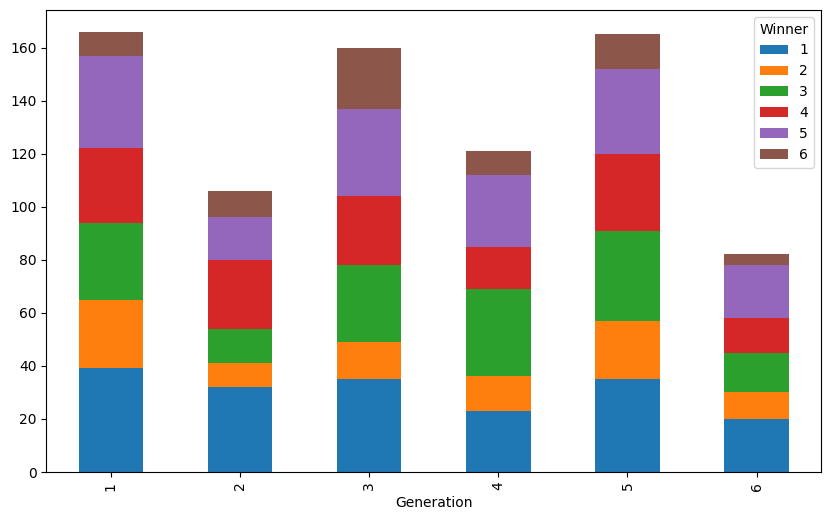

In [60]:
pd.crosstab(pokemon_df['Generation'], combat_df['Winner'].map(pokemon_df.set_index('#')['Generation'])).plot(kind='bar', stacked=True, figsize=(10,6))



## Normal Pokemon vs Legendary vs Mega-evolutions